# Human In The Loop




## Install dependencies
Run this once in a fresh environment.


In [1]:
# %pip -q install langgraph langchain-openai python-dotenv
# %pip install ipywidgets

## 1) Imports

In [2]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

## 2) Load environment variables - please read instructions carefully

In [3]:
# if you are running in local, uncomment below line. also make sure you shall have a .env file
load_dotenv()

True

In [4]:
# if you are running in google colab, uncomment below line. and replace "Your_API_Key" with your own openAI API key
#os.environ["OPENAI_API_KEY"] = "Your_API_Key"

## 3) Define Node

In [5]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0.4
)

# llm = ChatOpenAI(
#     model="gpt-4.1-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0.4
# )

class State(TypedDict):
    query: str
    route: str
    approved: bool
    answer: str


def classify_intent(state: State):
    response = llm.invoke(f"""
Classify this query into exactly one category:
technical
billing
general

Query: {state["query"]}

Return only one word.
""")

    route = response.content.strip().lower()

    if route not in ["technical", "billing", "general"]:
        route = "general"

    return {"route": route}

def human_review(state: State):
    human_input = interrupt({
        "question": "Please review the routing decision.",
        "query": state["query"],
        "suggested_route": state["route"],
        "options": ["technical", "billing", "general"]
    })

    return {
        "route": human_input["route"],
        "approved": True
    }

def route_decision(state: State) -> Literal["technical", "billing", "general"]:
    return state["route"]


def handle_technical(state: State):
    response = llm.invoke(
        f"You are a technical support expert. Answer this:\n{state['query']}"
    )
    return {"answer": response.content}


def handle_billing(state: State):
    response = llm.invoke(
        f"You are a billing support agent. Answer this:\n{state['query']}"
    )
    return {"answer": response.content}


def handle_general(state: State):
    response = llm.invoke(
        f"Answer this general question:\n{state['query']}"
    )
    return {"answer": response.content}



## 4) Build the graph

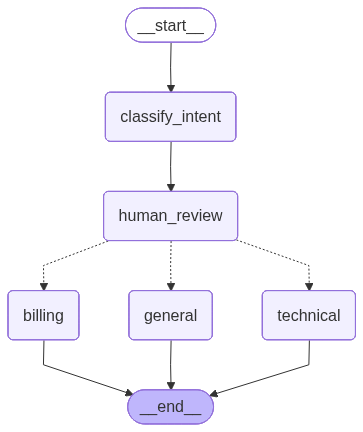

In [6]:
builder = StateGraph(State)

builder.add_node("classify_intent", classify_intent)
builder.add_node("human_review", human_review)
builder.add_node("technical", handle_technical)
builder.add_node("billing", handle_billing)
builder.add_node("general", handle_general)

builder.add_edge(START, "classify_intent")
builder.add_edge("classify_intent", "human_review")

builder.add_conditional_edges(
    "human_review",
    route_decision,
    {
        "technical": "technical",
        "billing": "billing",
        "general": "general",
    }
)

builder.add_edge("technical", END)
builder.add_edge("billing", END)
builder.add_edge("general", END)

memory = InMemorySaver()

graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 4) Run

In [7]:
config = {
    "configurable": {
        "thread_id": "human-review-demo-1"
    }
}
result = graph.invoke(
    {
        "query": "I was charged twice this month."
    },
    config=config
)

print(result)

{'query': 'I was charged twice this month.', 'route': 'billing', '__interrupt__': [Interrupt(value={'question': 'Please review the routing decision.', 'query': 'I was charged twice this month.', 'suggested_route': 'billing', 'options': ['technical', 'billing', 'general']}, id='7605459f0078b97ad31c604c4a289854')]}


In [8]:
# human_route = input("Approve or change route: technical / billing / general: ")
# result = graph.invoke(
#     Command(resume={
#         "route": human_route.strip().lower()
#     }),
#     config=config
# )

# print(result)

# print("\nFINAL ANSWER:")
# print(result.get("answer", "No answer generated yet. Check the result above."))

In [9]:
import ipywidgets as widgets
from IPython.display import display, Markdown

interrupt_info = result["__interrupt__"][0].value
suggested_route = interrupt_info["suggested_route"]

display(Markdown(f"### Suggested route: `{suggested_route}`"))

approve = widgets.RadioButtons(
    options=["Yes", "No"],
    description="Approve?",
    value="Yes"
)

new_route = widgets.Dropdown(
    options=["technical", "billing", "general"],
    description="New route:",
    value=suggested_route,
    disabled=True
)

def on_approve_change(change):
    new_route.disabled = change["new"] == "Yes"

approve.observe(on_approve_change, names="value")

display(approve, new_route)

### Suggested route: `billing`

RadioButtons(description='Approve?', options=('Yes', 'No'), value='Yes')

Dropdown(description='New route:', disabled=True, index=1, options=('technical', 'billing', 'general'), value=…

In [14]:
final_route = suggested_route if approve.value == "Yes" else new_route.value

result = graph.invoke(
    Command(resume={"route": final_route}),
    config=config
)

print(result["answer"])

I'm sorry to hear that you were charged twice this month. I'd be happy to help you resolve this. Could you please provide me with your account details and the dates or amounts of the charges you see? This will help me investigate the issue more quickly.
